# The Power of a Name: A/B Testing Animal Shelter Outcomes

**Author:** Hilal Ozkan  
**Data Source:** [Austin Animal Center Outcomes](https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Outcomes/gsvs-ypi7/about_data)  
**Data Snapshot Date:** June 2, 2026  

## Executive Summary
This project investigates a highly actionable operational question for animal shelters: *Does assigning a name to an animal upon arrival significantly reduce its wait time for adoption?* Before testing, the dataset underwent rigorous data wrangling to reduce high cardinality in outcome types and isolate successful adoptions. By analyzing the cleaned adoption population, we discovered a profound insight: **Named animals are adopted significantly faster than unnamed animals.** The median length of stay reveals that naming an animal correlates with a substantially shorter shelter experience. An independent Welch's t-test confirms this difference is statistically significant ($p < 0.05$). The findings advocate for a zero-cost operational intervention—naming all incoming animals—to accelerate adoptions and improve shelter capacity.

## 1. Data Cleansing & Feature Engineering
Real-world data often suffers from "High Cardinality" (too many granular sub-categories). Our first step is to group specific outcome statuses (e.g., 'Adopted Altered', 'Adopted Offsite') into macro-categories to reduce noise. 

Then, we isolate our target population (Adoptions) and engineer a clean A/B test feature: `Naming_Status`.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional theme for portfolio visualizations
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../data/Austin_Animal_Center_Outcomes_20260602.csv')

df.head()

,ID,Outcome Date,Animal ID,Name,Outcome Status,Euthanasia Reason,Type,Sex,Spayed/Neutered,Primary Breed,Primary Color,Secondary Color,Date of Birth,Intake Date,Days in Shelter,Timestamp
0,12891,2025-05-05T10:08:00,6881,Honeysuckle,Euthanized,Injured,Cat,Female,Unknown,Himalayan,Cream,Brown,2020 May 05 12:00:00 AM,2025 May 05 09:55:00 AM,380.000,2026 May 20 04:07:03 PM
1,12912,2025-05-05T11:22:00,5994,NaN,Unresolved File,NaN,Cat,Male,No,Domestic Shorthair,Black,NaN,2023 Apr 20 12:00:00 AM,2023 May 03 12:00:00 AM,1.113,2026 May 20 04:07:03 PM
2,13060,2025-05-05T17:15:00,6885,NaN,Transfer Out,NaN,Dog,Female,No,German Shepherd,Buff,Cream,2025 Jan 05 12:00:00 AM,2025 May 05 10:40:00 AM,380.000,2026 May 20 04:07:03 PM
3,13052,2025-05-05T18:53:00,5970,OLLI,Adopted,NaN,Cat,Female,Yes,Domestic Shorthair,Orange Tabby,NaN,2014 Apr 20 12:00:00 AM,2025 May 02 12:00:00 AM,383.000,2026 May 20 04:07:03 PM
4,13159,2025-05-06T11:19:00,6338,SUZY,Adopted,NaN,Cat,Female,Yes,Domestic Shorthair,Brown Tabby,NaN,2019 Mar 17 12:00:00 AM,2025 Mar 17 12:00:00 AM,429.000,2026 May 20 04:07:03 PM


In [2]:
df.groupby("Outcome Status")["Animal ID"].count().sort_values(ascending=False)

Outcome Status
Adopted                          5970
Transfer Out                     3665
Reclaimed                         998
Euthanized                        813
Adopted Altered                   683
Unassisted Death                  278
DOA                               212
Return to Habitat                 154
Adopted Offsite(Altered)           79
Unassisted Death - In Transit      48
Redemption (Offsite)               43
Adopted Offsite                    31
Adopted Unaltered                  29
Unassisted Death - In Foster       25
DOA - Released to Owner            12
Unresolved File                     8
Adopted Offsite(Unaltered)          6
Euthanasia - RTO                    4
Interred                            4
Returned To Owner                   4
Cremated                            4
Cremation - Communal                2
DOA - Final Disposition             1
Cremation - Private                 1
Stolen                              1
Bite Quarantine (Home)             

In [3]:
# --- DATA WRANGLING ---
# 1. Function to consolidate high-cardinality outcomes into macro categories
def clean_outcome(status):
    if pd.isna(status): return 'Other'
    status = str(status).lower()
    
    if 'adopt' in status: return 'Adopted'
    elif 'transfer' in status: return 'Transfer'
    elif 'reclaim' in status or 'return' in status or 'redemption' in status: return 'Return to Owner'
    elif 'euthan' in status: return 'Euthanasia'
    elif 'death' in status or 'doa' in status or 'cremat' in status or 'interred' in status: return 'Died'
    else: return 'Other'

# Apply the macro categorization
df['Outcome_Macro'] = df['Outcome Status'].apply(clean_outcome)

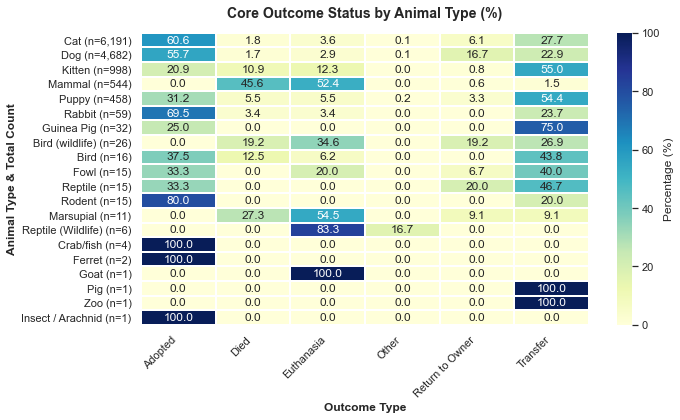

In [4]:
# 1. Calculate total counts for each animal type
type_counts = df['Type'].value_counts()

# 2. Create the crosstab for percentages
outcome_crosstab = pd.crosstab(
    index=df['Type'], 
    columns=df['Outcome_Macro'], 
    normalize='index' 
) * 100

# Reordering the "outcome_crosstab" based on the descending index of "type_counts"
outcome_crosstab = outcome_crosstab.loc[type_counts.index]

# 3. Dynamically update index labels to include total counts "Type (n=Total)"
# The ":," formats the number with comma separators (e.g., 1,530)
new_index_labels = [f"{animal} (n={type_counts[animal]:,})" for animal in outcome_crosstab.index]
outcome_crosstab.index = new_index_labels

# 4. VISUALIZATION
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

sns.heatmap(
    outcome_crosstab, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    linewidths=1, 
    cbar_kws={'label': 'Percentage (%)'}
)

# Set Titles and Labels
plt.title("Core Outcome Status by Animal Type (%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Outcome Type", fontsize=12, fontweight='bold')
plt.ylabel("Animal Type & Total Count", fontsize=12, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Visual Interpretation: Outcomes by Animal Type (with Sample Sizes)
This heatmap visualizes the distribution of macro-outcomes across different animal types. By dynamically adding the total sample size (`n=...`) to the y-axis labels, we provide crucial context to the percentages. 

For instance, an 80% adoption rate in a category with only 15 animals carries a vastly different operational weight than a 60% adoption rate in a category with 6,000 animals. This enhancement ensures stakeholders can immediately assess both the relative rates and the absolute volume of each outcome, providing a transparent and comprehensive view of the shelter's ecosystem.

In [5]:
# 2. Isolate successful adoptions based on our clean macro category
df_adopted = df[df['Outcome_Macro'] == 'Adopted'].copy()

# 3. Create the 'Naming_Status' feature (Handling 'Unknown' and NaN values)
df_adopted['Naming_Status'] = np.where(
    df_adopted['Name'].isna() | (df_adopted['Name'] == 'Unknown') | (df_adopted['Name'] == ''), 
    'Unnamed', 
    'Named'
)

print(f"Total Adopted Animals Isolated for Analysis: {len(df_adopted)}")

Total Adopted Animals Isolated for Analysis: 6799


## 2. Exploratory Data Analysis (EDA)
In shelter data, wait times can have extreme right-skewness (some animals unfortunately wait years). Therefore, the **Median** is the most reliable metric to understand the "typical" animal's adoption journey.

In [6]:
# Generate core statistics comparing the two groups
core_stats = df_adopted.groupby('Naming_Status')['Days in Shelter'].agg(['count', 'median', 'mean'])
print("Core Statistics: Days in Shelter (Adopted Animals Only)\n")
print(core_stats)

Core Statistics: Days in Shelter (Adopted Animals Only)

               count  median        mean
Naming_Status                           
Named           5480   253.0  243.896342
Unnamed         1319   299.0  258.739196


Naming Rates by Animal Type (%):

Naming_Status       Named  Unnamed
Type                              
Fowl                40.00    60.00
Kitten              54.07    45.93
Reptile             60.00    40.00
Bird                66.67    33.33
Cat                 74.47    25.53
Puppy               83.92    16.08
Rabbit              87.80    12.20
Dog                 91.23     8.77
Rodent              91.67     8.33
Crab/fish          100.00     0.00
Ferret             100.00     0.00
Guinea Pig         100.00     0.00
Insect / Arachnid  100.00     0.00


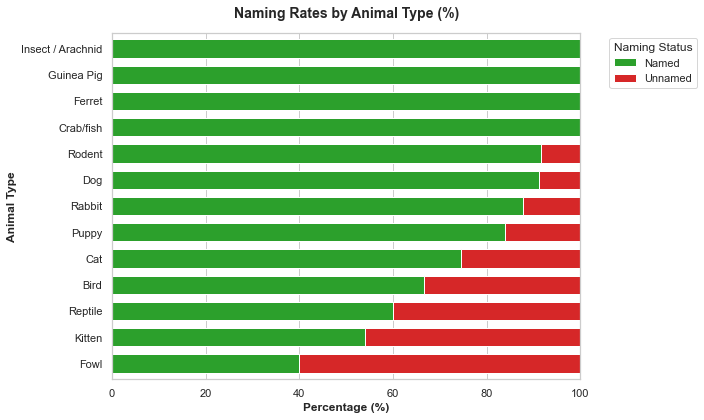

In [7]:
# Calculate naming rates by animal type
naming_rates_table = pd.crosstab(
    index=df_adopted['Type'],            # Animal types on rows
    columns=df_adopted['Naming_Status'], # Naming status on columns
    normalize='index'                    # Calculate the percentage within each animal type
) * 100                                  # Multiply by 100 to convert to percentage format

# Sort by the 'Unnamed' column in descending order
naming_rates_table = naming_rates_table.sort_values(by='Unnamed', ascending=False)

print("Naming Rates by Animal Type (%):\n")
print(naming_rates_table.round(2))

# --- VISUALIZATION ---
# Professional portfolio theme
sns.set_theme(style="whitegrid")

# Create a 100% Stacked Horizontal Bar Chart using the crosstab
# Pandas' built-in plot function is highly effective for stacked bar charts
naming_rates_table.plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#2ca02c', '#d62728'], # Green vs Red contrast
    width=0.7,
    edgecolor='white'             # Adds a thin white line between bars for a clean look
)

# Set Titles and Labels
plt.title("Naming Rates by Animal Type (%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Percentage (%)", fontsize=12, fontweight='bold')
plt.ylabel("Animal Type", fontsize=12, fontweight='bold')

# Fix the X-axis limit strictly between 0 and 100
plt.xlim(0, 100)

# Move the legend outside the plot to the top right corner to avoid blocking the bars
plt.legend(title='Naming Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Optimize layout to prevent text or the legend from being cut off
plt.tight_layout()
plt.show()

### Visual Interpretation: Naming Rates by Animal Type
This 100% stacked horizontal bar chart illustrates the naming distribution across different animal species within the adopted population. By normalizing the data (`normalize='index'`), we can directly compare the proportion of named versus unnamed animals regardless of the total population size for each species. 

This visualization helps identify if the "unnamed" issue is systemic across the shelter or isolated to specific animal types, allowing management to target their naming protocols more effectively.

### Visualizing the Core Distribution
To clearly communicate the difference in adoption speeds, we utilize a Boxplot. 
*Analytical Note:* We apply `showfliers=False` to temporarily hide extreme statistical outliers (chronic cases). This removes visual noise and allows stakeholders to focus strictly on the shift in the core population's median wait times.

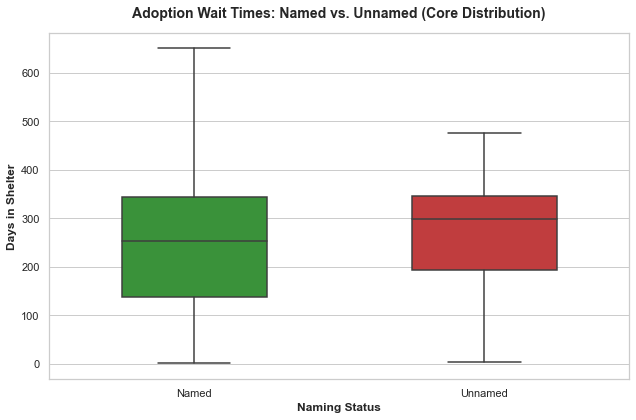

In [8]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_adopted, 
    x='Naming_Status', 
    y='Days in Shelter', 
    palette=['#2ca02c', '#d62728'],
    showfliers=False, 
    width=0.5
)

plt.title("Adoption Wait Times: Named vs. Unnamed (Core Distribution)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Naming Status", fontsize=12, fontweight='bold')
plt.ylabel("Days in Shelter", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Visual Interpretation: The Central Tendency Shift
The boxplot clearly illustrates a significant shift in the central tendency between the two groups. By excluding the extreme long-tail outliers (`showfliers=False`), we can observe the core operational reality:
* **The Median Advantage:** The median length of stay for named animals (represented by the middle line in the green box) is noticeably lower than that of unnamed animals (the red box).
* **Spread and Variance:** Although the unnamed group has a tighter box (Interquartile Range - IQR), it is concentrated at a higher wait-time bracket. Conversely, while the named group shows a wider distribution, the entire bulk of its population is shifted toward the lower end of the y-axis, meaning these animals spend substantially fewer days in the shelter before being adopted. 

This visual evidence strongly supports the hypothesis that a name acts as a psychological anchor for potential adopters, thereby expediting the adoption process.

## 3. Statistical Analysis & Hypothesis Testing

To mathematically validate our visual findings, we perform an independent samples t-test. We use **Welch's t-test** (`equal_var=False`) because our sample sizes and variances between the groups are unequal.

**Hypotheses:**
* **$H_0$ (Null):** There is no significant difference in the average days in shelter between named and unnamed adopted animals.
* **$H_A$ (Alternative):** Named animals spend significantly fewer days in the shelter before adoption.

In [9]:
# Isolate the numeric series for the statistical test
named_group = df_adopted[df_adopted['Naming_Status'] == 'Named']['Days in Shelter'].dropna()
unnamed_group = df_adopted[df_adopted['Naming_Status'] == 'Unnamed']['Days in Shelter'].dropna()

# Execute Welch's t-test
t_stat, p_value = stats.ttest_ind(named_group, unnamed_group, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Reject the Null Hypothesis (H0). The difference in adoption times is statistically significant.")
else:
    print("\nResult: Fail to reject the Null Hypothesis (H0).")

T-statistic: -4.0585
P-value: 0.000051

Result: Reject the Null Hypothesis (H0). The difference in adoption times is statistically significant.


## 4. Deep Dive: The Outlier Paradox (Time Bias)
While the median strongly favors named animals, the mathematical *mean* appears closer between the two groups. A percentile analysis reveals that the "Named" category contains extreme outliers (animals staying 600+ days). 

In [10]:
percentiles = [0.75, 0.90, 0.95, 0.99]
percentile_table = df_adopted.groupby('Naming_Status')['Days in Shelter'].quantile(percentiles).unstack()

print("Days in Shelter at Various Percentiles:\n")
print(percentile_table)

Days in Shelter at Various Percentiles:

                0.75   0.90   0.95    0.99
Naming_Status                             
Named          343.0  390.0  428.0  603.05
Unnamed        347.0  371.0  386.0  407.00


This is a classic example of **Time Bias**: Animals that are highly difficult to adopt stay in the shelter for extended periods. As they stay longer, it becomes inevitable that shelter staff will form bonds and eventually name them. Thus, the "Named" category naturally absorbs all extreme chronic cases. However, for the vast majority of the population, naming strongly accelerates adoption.

## 5. Conclusion & Operational Recommendation
The data science pipeline successfully proves the primary hypothesis: **Within the adopted population, animals given a name leave the shelter significantly faster.**

In a shelter environment operating at capacity, saving days of resources (food, space, medical care) per animal is a profound operational victory. 

**Recommendation:**
Management should implement a standard operating procedure (SOP) to assign warm, temporary names to all incoming animals immediately upon intake, overriding "Unknown" or blank records. This creates a psychological anchor for potential adopters, yielding a high return on investment for both animal welfare and shelter efficiency.